# Week 3 - Python & Data Wrangling

## Data Cleaning and Analysis

This project demonstrates data cleaning, filtering, 
new column creation, and data visualization using 
Python, Pandas, Matplotlib, and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/data.csv")
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01',110,130,409.1
1,60,2020/12/02',117,145,479.0
2,60,2020/12/03',103,135,340.0
3,45,2020/12/04',109,175,282.4
4,45,2020/12/05',117,148,406.0
5,60,2020/12/06',102,127,300.0
6,60,2020/12/07',110,136,374.0
7,450,2020/12/08',104,134,253.3
8,30,2020/12/09',109,133,195.1
9,60,2020/12/10',98,124,269.0


In [3]:
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01',110,130,409.1
1,60,2020/12/02',117,145,479.0
2,60,2020/12/03',103,135,340.0
3,45,2020/12/04',109,175,282.4
4,45,2020/12/05',117,148,406.0


In [4]:
df.tail()

,Duration,Date,Pulse,Maxpulse,Calories
27,60,2020/12/27',92,118,241.0
28,60,2020/12/28',103,132,NaN
29,60,2020/12/29',100,132,280.0
30,60,2020/12/30',102,129,380.3
31,60,2020/12/31',92,115,243.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


In [6]:
df.shape

(32, 5)

In [7]:
df.columns

Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='str')

In [8]:
df.isnull().sum()

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Date"] = pd.to_datetime(df["Date"],errors="coerce")

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 31 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  31 non-null     int64         
 1   Date      29 non-null     datetime64[us]
 2   Pulse     31 non-null     int64         
 3   Maxpulse  31 non-null     int64         
 4   Calories  29 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 1.5 KB


In [15]:
df["Date"].isnull().sum()

np.int64(2)

In [16]:
df["Date"] = df["Date"].ffill()

In [17]:
df["Date"].isnull().sum()

np.int64(0)

In [18]:
df["Calories"].isnull().sum()

np.int64(2)

In [19]:
df["Calories"] = df["Calories"].fillna(df["Calories"].median())

In [20]:
df["Calories"].isnull().sum()

np.int64(0)

In [21]:
df.isnull().sum()

Duration    0
Date        0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64

In [22]:
df["Calories_per_Minute"] = df["Calories"] / df["Duration"]

In [23]:
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute
0,60,2020-12-01,110,130,409.1,6.818333
1,60,2020-12-02,117,145,479.0,7.983333
2,60,2020-12-03,103,135,340.0,5.666667
3,45,2020-12-04,109,175,282.4,6.275556
4,45,2020-12-05,117,148,406.0,9.022222


In [24]:
df["Intensity"] =np.where(
    df["Pulse"] >= 100,
    "High",
    "Normal"
)

In [25]:
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Intensity
0,60,2020-12-01,110,130,409.1,6.818333,High
1,60,2020-12-02,117,145,479.0,7.983333,High
2,60,2020-12-03,103,135,340.0,5.666667,High
3,45,2020-12-04,109,175,282.4,6.275556,High
4,45,2020-12-05,117,148,406.0,9.022222,High


In [26]:
high_pulse = df[df["Pulse"] > 100]
high_pulse

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Intensity
0,60,2020-12-01,110,130,409.1,6.818333,High
1,60,2020-12-02,117,145,479.0,7.983333,High
2,60,2020-12-03,103,135,340.0,5.666667,High
3,45,2020-12-04,109,175,282.4,6.275556,High
4,45,2020-12-05,117,148,406.0,9.022222,High
5,60,2020-12-06,102,127,300.0,5.000000,High
6,60,2020-12-07,110,136,374.0,6.233333,High
7,450,2020-12-08,104,134,253.3,0.562889,High
8,30,2020-12-09,109,133,195.1,6.503333,High
10,60,2020-12-11,103,147,329.3,5.488333,High


In [27]:
df.describe()

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute
count,31.000000,31,31.000000,31.000000,31.000000,31.000000
mean,68.709677,2020-12-15 22:27:05.806451,103.612903,128.774194,306.119355,5.404161
min,30.000000,2020-12-01 00:00:00,90.000000,101.000000,195.100000,0.562889
25%,60.000000,2020-12-08 12:00:00,100.000000,120.000000,252.000000,4.625000
50%,60.000000,2020-12-16 00:00:00,103.000000,128.000000,300.000000,5.466667
75%,60.000000,2020-12-23 12:00:00,107.000000,132.500000,342.650000,6.271111
max,450.000000,2020-12-31 00:00:00,130.000000,175.000000,479.000000,9.022222
std,71.180144,NaN,7.935899,13.119222,64.136367,1.476243


In [28]:
df["Calories"].mean()

np.float64(306.1193548387096)

In [29]:
df["Calories"].max()

np.float64(479.0)

In [30]:
df["Pulse"].mean()

np.float64(103.61290322580645)

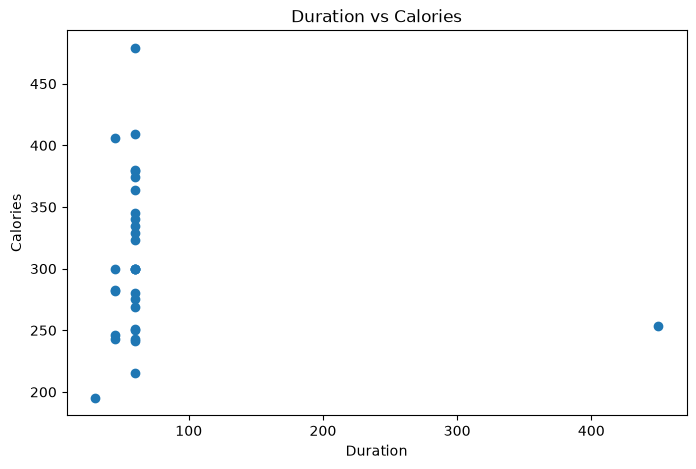

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df["Duration"],df["Calories"])
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.title("Duration vs Calories")
plt.show()

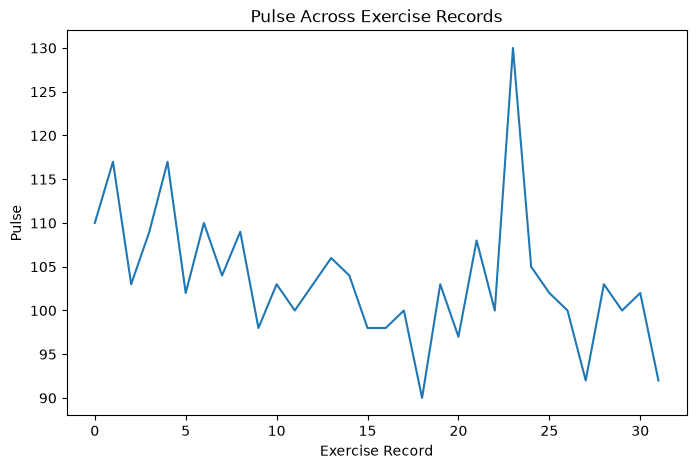

In [31]:
plt.figure(figsize=(8,5))
plt.plot(df["Pulse"])
plt.xlabel("Exercise Record")
plt.ylabel("Pulse")
plt.title("Pulse Across Exercise Records")
plt.show()

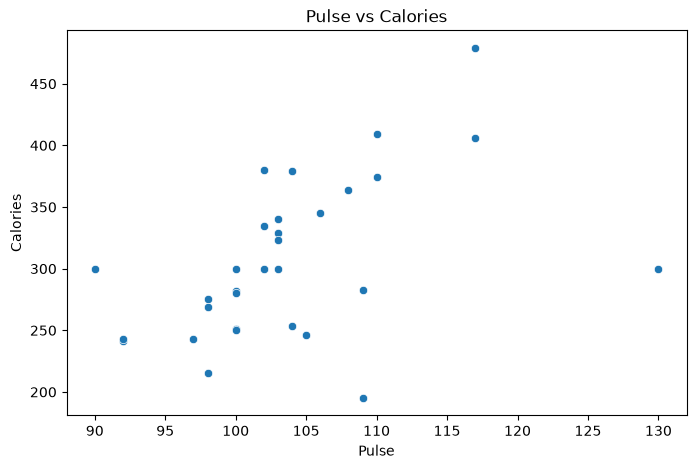

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Pulse",
    y="Calories"
)
plt.title("Pulse vs Calories")
plt.show()

In [34]:
df.to_csv("cleaned_data.csv",index=False)